In [11]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

Load MNIST Dataset

In [12]:
# Transform: convert images to tensor
transform = transforms.ToTensor()

# Load training data
train_data = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Load test data
test_data = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))

100%|██████████| 9.91M/9.91M [00:29<00:00, 338kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 94.8kB/s]
100%|██████████| 1.65M/1.65M [00:03<00:00, 421kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.13MB/s]


Training samples: 60000
Testing samples: 10000


In [13]:
images, labels = next(iter(torch.utils.data.DataLoader(train_data, batch_size=32)))

print("Image batch shape:", images.shape)  # (32, 1, 28, 28)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([32, 1, 28, 28])
Label batch shape: torch.Size([32])


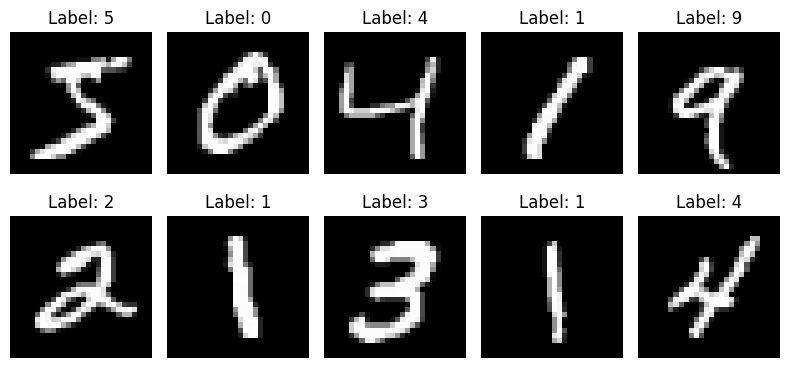

In [14]:
plt.figure(figsize=(8,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(train_data.data[i], cmap='gray')
    plt.title(f"Label: {train_data.targets[i].item()}")
    plt.axis('off')

plt.tight_layout()
plt.show()

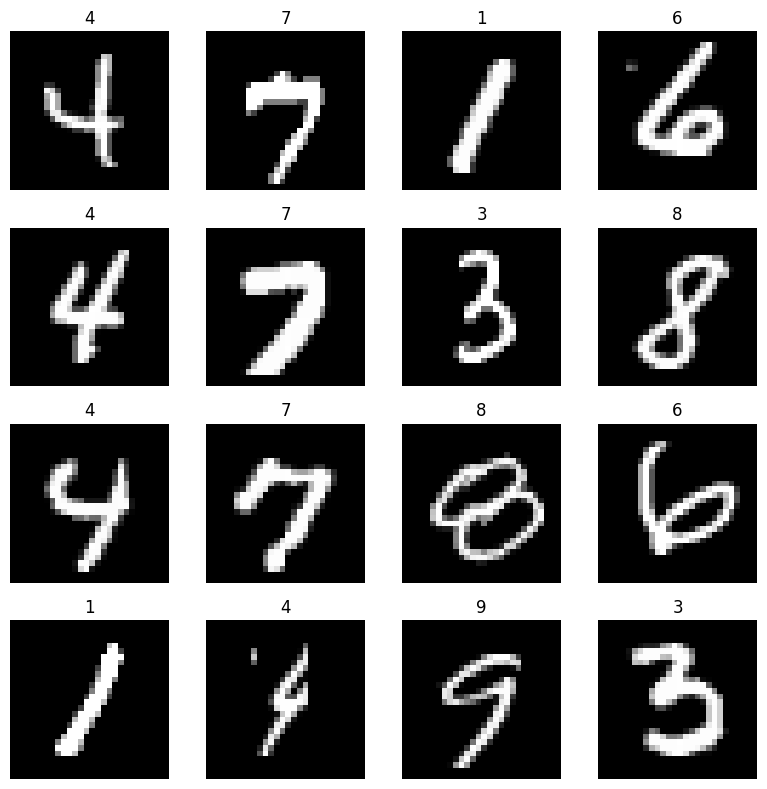

In [15]:
plt.figure(figsize=(8,8))

for i in range(16):
    index = np.random.randint(0, len(train_data))
    image, label = train_data[index]

    plt.subplot(4,4,i+1)
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

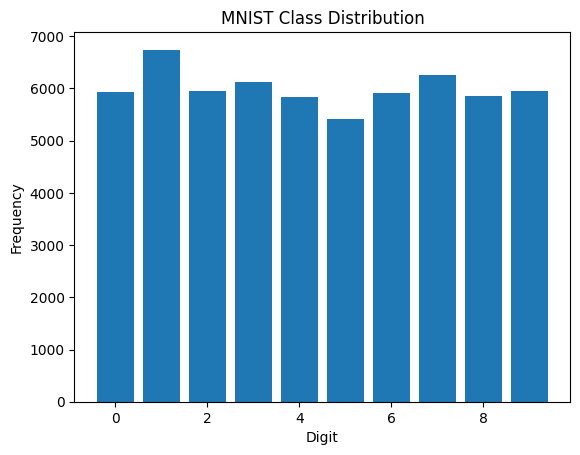

In [16]:
labels = train_data.targets.numpy()

unique, counts = np.unique(labels, return_counts=True)

plt.bar(unique, counts)
plt.xlabel("Digit")
plt.ylabel("Frequency")
plt.title("MNIST Class Distribution")
plt.show()

In [17]:
print("Min pixel value:", train_data.data.min())
print("Max pixel value:", train_data.data.max())

Min pixel value: tensor(0, dtype=torch.uint8)
Max pixel value: tensor(255, dtype=torch.uint8)


Before normalization: 0.0 1.0


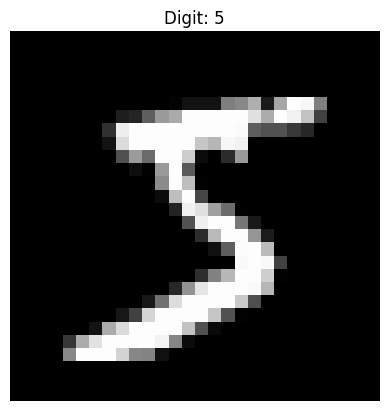

In [18]:
# Normalize image (0–1)
image, label = train_data[0]

print("Before normalization:", image.min().item(), image.max().item())

# Already normalized because of ToTensor()
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Digit: {label}")
plt.axis('off')
plt.show()